In [5]:
import numpy as np
path0 = './'
filename = 'all_candidate_paraphrase_pairs.txt'
threshold = 0.65  # adjust this value as needed

data = []
with open(f"{path0}{filename}", "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 9:
            (sentence1, sentence2, original, paraphrase, 
             tags1, tags2, len1, len2, word_overlap) = parts
            try:
                if float(word_overlap) < threshold and int(len1) > 5 and int(len2) > 5:
                    data.append((sentence1, sentence2, original, len1, len2))
            except ValueError:
                continue  # skip lines with non-numeric word_overlap

print(f'{len(data)=}')

for i in range(2):
    print(data[i])

len(data)=2018
('After falling to the ground, the child cried', 'The child fell on the ground and cried', 'The child fell on the ground and cried', '8', '9')
('That master tune rings with eternal beauty', 'The music composed by a master sounds timeless', 'The music composed by a master sounds timeless', '8', '7')


In [6]:
count_first = 0
count_second = 0

with open(filename, "r") as f:
  for parts in data:
    if len(parts) >= 3:
      if parts[2] == parts[0]:
        count_first += 1
      elif parts[2] == parts[1]:
        count_second += 1

print(f"Third column equals first column: {count_first} times")
print(f"Third column equals second column: {count_second} times")

Third column equals first column: 1034 times
Third column equals second column: 984 times


In [7]:
# # 3. Open five files and write out
# with open(f"{path0}sentences0.txt", "w") as f1, \
#      open(f"{path0}sentences1.txt", "w") as f2:
#     for s1,s2,_,_,_ in data:
#         f1.write(s1 + "\n")
#         f2.write(s2 + "\n")

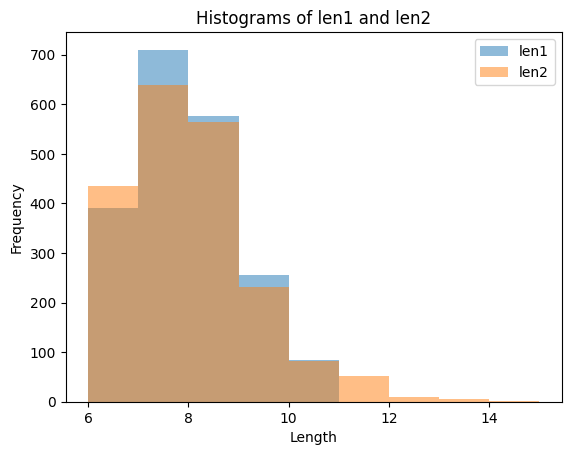

In [8]:
import matplotlib.pyplot as plt

# Extract len1 and len2 as integers
len1_list = [int(item[3]) for item in data]
len2_list = [int(item[4]) for item in data]

plt.hist(len1_list, bins=range(min(len1_list), max(len1_list)+2), alpha=0.5, label='len1')
plt.hist(len2_list, bins=range(min(len2_list), max(len2_list)+2), alpha=0.5, label='len2')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histograms of len1 and len2')
plt.show()

### Removing syntax experiment

In [13]:
def get_group_ids(data, 
                  file1_path, 
                  file2_path, 
                  group_ids_path, 
                  ):
  # Read all lines from the first file into a list and dict for fast lookup
  with open(file1_path, "r") as f1:
    lines1 = [line.strip() for line in f1]
    line_to_idx1 = {line: idx for idx, line in enumerate(lines1)}
  # Read all lines from the second file into a list and dict for fast lookup
  with open(file2_path, "r") as f2:
    lines2 = [line.strip() for line in f2]
    line_to_idx2 = {line: idx for idx, line in enumerate(lines2)}
  # Read group ids
  with open(group_ids_path, "r") as fgid:
    original_group_ids = [line.strip() for line in fgid]

  results = []

  for data_idx, (sentence1, sentence2, original, _, _) in enumerate(data):

    ### First we check if the original sentence is in either file
    if original in line_to_idx1:
      original_in_1 = True
    else:
      original_in_1 = False 

    if original in line_to_idx2:
      original_in_2 = True
    else:
      original_in_2 = False

    if original == sentence1:
      label = 0
    elif original == sentence2:
      label = 1
    else:
      print('ERROR') ; break

    if original_in_1:
      idx1 = line_to_idx1[original]
      group_id1 = original_group_ids[idx1] 
      results.append((data_idx, label, int(group_id1)))
    elif original_in_2:
      idx2 = line_to_idx2[original]
      group_id2 = original_group_ids[idx2]
      results.append((data_idx, label, int(group_id2)))
    else:
        print(f"[MISSING] '{original}' {data_idx=})")

  return results

file1 = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/sentences0.txt"
file2 = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/sentences1.txt"
group_ids_path = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/group_ids.txt"

""" Given the dataset of paraphrases, I use the label of who’s the 
"original" sentence (as opposed to its corresponding paraphrase). 
For that one, I have its "syntax group id", and then I can subtract to it
its corresponding "average syntax group center" vector, 
that I computed in the previous experiment. Note that this modification is only performed
in one of the feature spaces at a time.
"""
results = get_group_ids(
                        data, file1, file2, group_ids_path,
                      )

print(f'{len(results)=}')
for i in range(5):
  print(results[i])

[MISSING] 'He is fighting a difficult battle bravely' data_idx=8)
[MISSING] 'Sony invested in a new gaming console' data_idx=9)
[MISSING] 'The president hoped to deliver their promise' data_idx=10)
[MISSING] 'She texted her but she was busy' data_idx=13)
[MISSING] 'The gardener tended the plants diligently to promote growth' data_idx=22)
[MISSING] 'He is tasting the soup cautiously' data_idx=25)
[MISSING] 'Few countries may join the treaty' data_idx=26)
[MISSING] 'The community gathered to support the cause' data_idx=27)
[MISSING] 'A gift given by a friend is always special' data_idx=32)
[MISSING] 'The program continued to run the course' data_idx=33)
[MISSING] 'The customer chose to buy the item' data_idx=41)
[MISSING] 'The stars shine so bright in the sky' data_idx=42)
[MISSING] 'Several politicians may oppose the bill' data_idx=59)
[MISSING] 'I need a book from the library' data_idx=65)
[MISSING] 'The light filled the room and the shadows disappeared quickly' data_idx=66)
[MISSING] 

len(original_labels)=1612


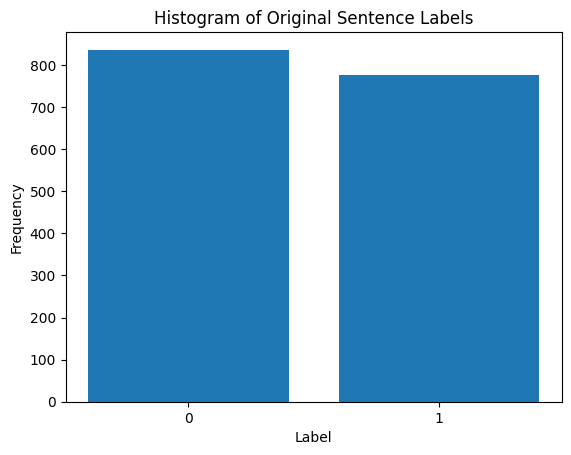

In [10]:
original_labels = [label for _, label, _ in results]
print(f'{len(original_labels)=}')
plt.hist(original_labels, bins=[-0.5, 0.5, 1.5], rwidth=0.8)
plt.xticks([0, 1])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('Histogram of Original Sentence Labels')
plt.show()

In [8]:
output_path_group_ids = "group_ids.txt"

L = 1600
counter = 0
selected_indices = []

with open(output_path_group_ids, "w") as f_groups:
    with open(f"original_labels.txt", "w") as f_labels:
      for data_idx, label, group_id in results:
          if counter < L:
            f_groups.write(f"{group_id}\n")
            counter += 1
            selected_indices.append(data_idx)
            f_labels.write(f"{label}\n")
len(selected_indices)

1600

In [9]:
# with open("sentences0.txt", "w") as f1, open("sentences1.txt", "w") as f2:
#   for idx in selected_indices:
#     s1, s2, *_ = data[idx]
#     f1.write(s1 + "\n")
#     f2.write(s2 + "\n")

In [ ]:
### !!! CHECKING THIS IDEA, ORIGINALS TO SENTENCES0.TXT
with open("sentences0.txt", "w") as f1, \
  open("sentences1.txt", "w") as f2, \
  open(f"original_labels.txt", "w") as f_labels:
  for idx in selected_indices:
    original, paraphrase = data[idx][2], data[idx][0] if data[idx][2] != data[idx][0] else data[idx][1]
    f1.write(original + "\n")
    f2.write(paraphrase + "\n")
    f_labels.write(f"0\n")

### DBG

In [11]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
import jax.numpy as jnp
A = jnp.array([1,2,3,4,5,6,7,8,9,10])
B = jnp.array([2,3,4,5,3])
C = jnp.array([0,-1])
A[B[C]]


Array([3, 4], dtype=int32)